# Hyperparameter Search Analysis
Local analysis of WeightedMSELoss penalty λ search results from v1 (λ∈{5–15}) and v2 (λ∈{15–30}).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import warnings
warnings.filterwarnings('ignore')

# Load both search CSVs
df1 = pd.read_csv('hyperparameter_search_results.csv').dropna(subset=['lam'])
df2 = pd.read_csv('hyperparameter_search_results_v2.csv').dropna(subset=['lam'])

df1['search'] = 'v1 (λ=5–15)'
df2['search'] = 'v2 (λ=15–30)'

df = pd.concat([df1, df2], ignore_index=True)
df['lam'] = df['lam'].astype(int)

print(f'Total runs: {len(df)}  (v1={len(df1)}, v2={len(df2)})')
df.head()

Total runs: 60  (v1=30, v2=30)


,lam,lr,dropout,global_r2,global_mae,city_r2,city_mae,city_underprediction,city15_r2,city15_mae,city15_underprediction,pred_max,search
0,5,0.000123,0.2,0.178134,0.023002,-2.371845,0.173668,55.524086,-1.593227,0.133889,55.538822,0.418529,v1 (λ=5–15)
1,8,0.000301,0.3,0.150171,0.025128,-2.716548,0.181448,59.313236,-1.728026,0.134340,57.963573,0.304854,v1 (λ=5–15)
2,5,0.000709,0.3,0.207040,0.023756,-3.002736,0.197649,65.213870,-1.986955,0.147546,64.288570,0.276608,v1 (λ=5–15)
3,5,0.000631,0.1,0.169485,0.023066,-2.981798,0.196526,64.783646,-1.979791,0.147494,63.934180,0.391290,v1 (λ=5–15)
4,5,0.000184,0.1,0.195571,0.023064,-3.106441,0.203956,67.139694,-2.049847,0.150923,65.562775,0.414910,v1 (λ=5–15)


## Best runs per λ

In [2]:
# Best run per lambda (highest global_r2)
best_per_lam = df.loc[df.groupby('lam')['global_r2'].idxmax()].sort_values('lam')

print('Best run per λ (by global R²):')
print(best_per_lam[['lam','lr','dropout','global_r2','global_mae',
                     'city_r2','city_mae','city_underprediction',
                     'city15_underprediction','pred_max']].to_string(index=False))

Best run per λ (by global R²):
 lam       lr  dropout  global_r2  global_mae   city_r2  city_mae  city_underprediction  city15_underprediction  pred_max
   5 0.000870      0.1   0.207898    0.023168 -2.976965  0.198945             65.532150               64.089990  0.364948
   8 0.000728      0.2   0.192289    0.023591 -2.700433  0.182810             59.409435               59.258495  0.339227
  10 0.000240      0.2   0.195458    0.024516 -2.683733  0.184233             59.228410               59.565690  0.389114
  12 0.000442      0.3   0.186176    0.024718 -2.730789  0.182964             59.532692               59.922565  0.325740
  15 0.000972      0.3   0.151243    0.026393 -2.587238  0.176824             56.772762               55.862617  0.326046
  20 0.000186      0.3   0.095981    0.028142 -2.422374  0.172382             55.549137               52.928490  0.341255
  25 0.000145      0.3   0.044672    0.029200 -2.515886  0.174691             56.655080               53.791046  0.

In [3]:
# Best run per lambda (lowest city underprediction at τ=0.15)
best_city15 = df.loc[df.groupby('lam')['city15_underprediction'].idxmin()].sort_values('lam')

print('Best run per λ (lowest city underprediction at τ=0.15):')
print(best_city15[['lam','lr','dropout','global_r2','city15_underprediction',
                    'city_underprediction','pred_max']].to_string(index=False))

Best run per λ (lowest city underprediction at τ=0.15):
 lam       lr  dropout  global_r2  city15_underprediction  city_underprediction  pred_max
   5 0.000123      0.2   0.178134               55.538822             55.524086  0.418529
   8 0.000922      0.3   0.112388               51.953410             53.461693  0.305727
  10 0.000863      0.3   0.171967               55.508095             55.555992  0.308998
  12 0.000583      0.2   0.101895               55.257774             56.289590  0.348715
  15 0.000478      0.2   0.088448               52.018760             53.339100  0.352931
  20 0.000617      0.2   0.085417               51.649803             52.893925  0.371295
  25 0.000618      0.2  -0.059394               47.338604             49.281870  0.382211
  30 0.000970      0.3  -0.165443               46.212112             50.616920  0.333974


## Overview plots

Saved hyperparameter_search_analysis.png


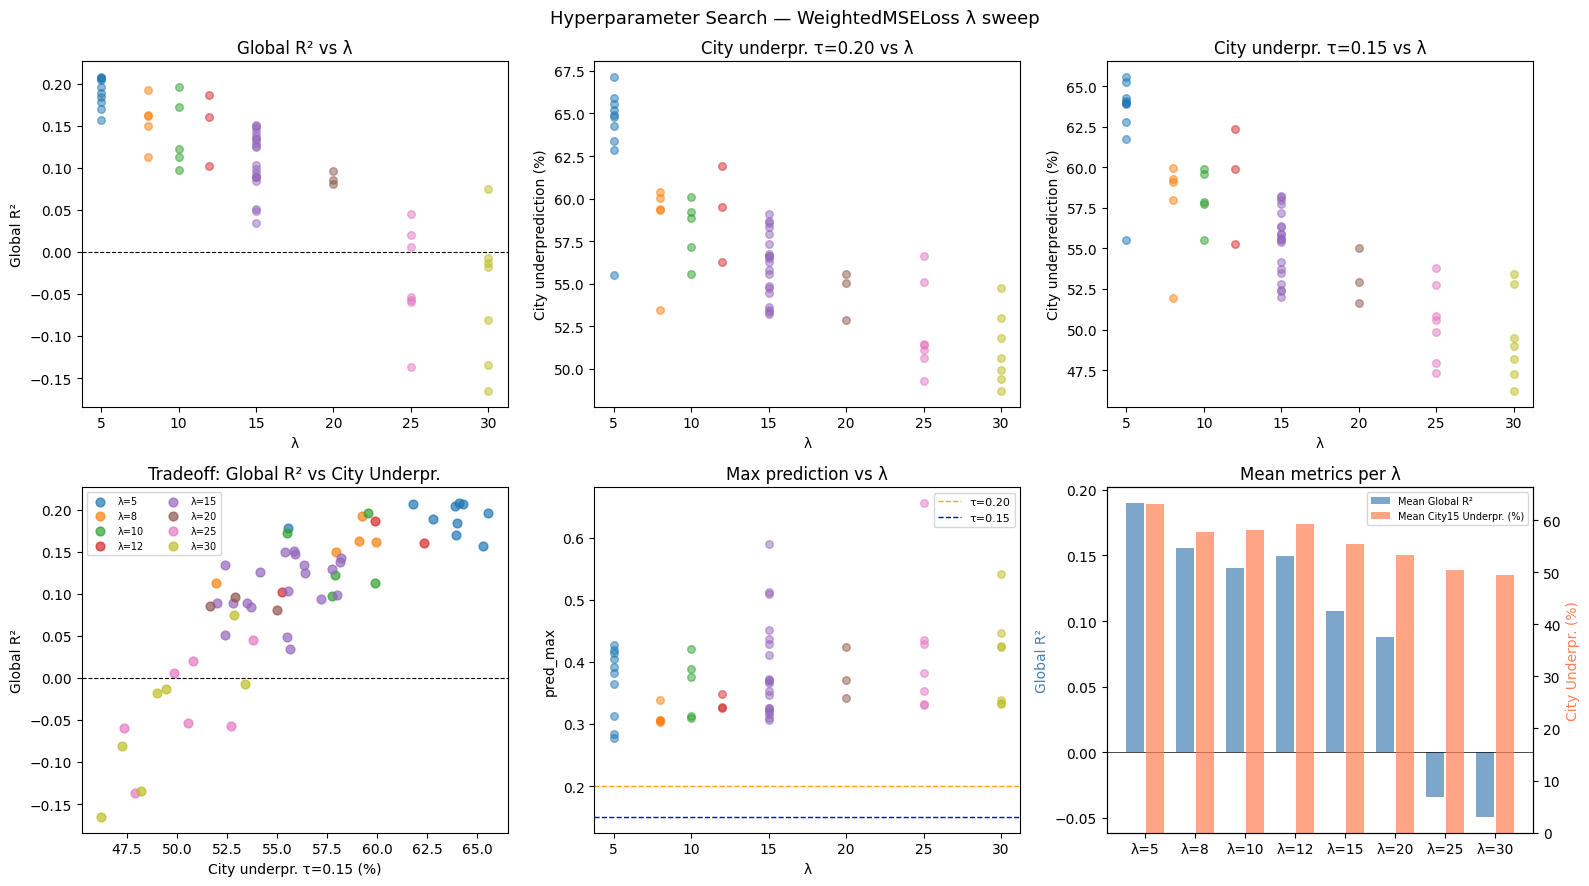

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Hyperparameter Search — WeightedMSELoss λ sweep', fontsize=13)

lam_vals = sorted(df['lam'].unique())
colors = cm.tab10(np.linspace(0, 0.8, len(lam_vals)))
color_map = {lam: c for lam, c in zip(lam_vals, colors)}

# 1. Global R² vs λ
ax = axes[0, 0]
for lam in lam_vals:
    sub = df[df['lam'] == lam]
    ax.scatter([lam]*len(sub), sub['global_r2'], alpha=0.5, color=color_map[lam], s=30)
ax.axhline(0, color='k', lw=0.8, ls='--')
ax.set_xlabel('λ')
ax.set_ylabel('Global R²')
ax.set_title('Global R² vs λ')

# 2. City underprediction (τ=0.20) vs λ
ax = axes[0, 1]
for lam in lam_vals:
    sub = df[df['lam'] == lam]
    ax.scatter([lam]*len(sub), sub['city_underprediction'], alpha=0.5, color=color_map[lam], s=30)
ax.set_xlabel('λ')
ax.set_ylabel('City underprediction (%)')
ax.set_title('City underpr. τ=0.20 vs λ')

# 3. City underprediction (τ=0.15) vs λ
ax = axes[0, 2]
for lam in lam_vals:
    sub = df[df['lam'] == lam]
    ax.scatter([lam]*len(sub), sub['city15_underprediction'], alpha=0.5, color=color_map[lam], s=30)
ax.set_xlabel('λ')
ax.set_ylabel('City underprediction (%)')
ax.set_title('City underpr. τ=0.15 vs λ')

# 4. Tradeoff: global R² vs city underprediction (τ=0.15)
ax = axes[1, 0]
for lam in lam_vals:
    sub = df[df['lam'] == lam]
    sc = ax.scatter(sub['city15_underprediction'], sub['global_r2'],
                    alpha=0.7, color=color_map[lam], s=40, label=f'λ={lam}')
ax.axhline(0, color='k', lw=0.8, ls='--')
ax.set_xlabel('City underpr. τ=0.15 (%)')
ax.set_ylabel('Global R²')
ax.set_title('Tradeoff: Global R² vs City Underpr.')
ax.legend(fontsize=7, ncol=2)

# 5. pred_max vs λ
ax = axes[1, 1]
for lam in lam_vals:
    sub = df[df['lam'] == lam]
    ax.scatter([lam]*len(sub), sub['pred_max'], alpha=0.5, color=color_map[lam], s=30)
ax.axhline(0.2, color='orange', lw=1, ls='--', label='τ=0.20')
ax.axhline(0.15, color='blue', lw=1, ls='--', label='τ=0.15')
ax.set_xlabel('λ')
ax.set_ylabel('pred_max')
ax.set_title('Max prediction vs λ')
ax.legend(fontsize=8)

# 6. Mean metrics per λ (bar chart)
ax = axes[1, 2]
mean_per_lam = df.groupby('lam')[['global_r2', 'city15_underprediction']].mean()
x = np.arange(len(mean_per_lam))
ax2 = ax.twinx()
bars = ax.bar(x - 0.2, mean_per_lam['global_r2'], 0.35, label='Mean Global R²', color='steelblue', alpha=0.7)
bars2 = ax2.bar(x + 0.2, mean_per_lam['city15_underprediction'], 0.35,
                label='Mean City15 Underpr. (%)', color='coral', alpha=0.7)
ax.set_xticks(x)
ax.set_xticklabels([f'λ={l}' for l in mean_per_lam.index])
ax.set_ylabel('Global R²', color='steelblue')
ax2.set_ylabel('City Underpr. (%)', color='coral')
ax.set_title('Mean metrics per λ')
ax.axhline(0, color='k', lw=0.5)
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, fontsize=7)

plt.tight_layout()
plt.savefig('hyperparameter_search_analysis.png', dpi=150, bbox_inches='tight')
print('Saved hyperparameter_search_analysis.png')
plt.show()

## Top 10 runs overall

In [5]:
# Composite score: balance R² and city underprediction
# Normalize both metrics to [0,1] then combine
r2_min, r2_max = df['global_r2'].min(), df['global_r2'].max()
uc_min, uc_max = df['city15_underprediction'].min(), df['city15_underprediction'].max()

df['r2_norm']  = (df['global_r2'] - r2_min) / (r2_max - r2_min)
df['uc_norm']  = 1 - (df['city15_underprediction'] - uc_min) / (uc_max - uc_min)  # lower is better
df['score']    = 0.5 * df['r2_norm'] + 0.5 * df['uc_norm']  # equal weight

top10 = df.nlargest(10, 'score')[['lam','lr','dropout','global_r2','global_mae',
                                   'city15_underprediction','city_underprediction',
                                   'pred_max','score','search']]
print('Top 10 runs (balanced score: 50% R², 50% city underprediction):')
print(top10.to_string(index=False))

Top 10 runs (balanced score: 50% R², 50% city underprediction):
 lam       lr  dropout  global_r2  global_mae  city15_underprediction  city_underprediction  pred_max    score       search
  15 0.000897      0.2   0.134045    0.025193               52.406097             53.433155  0.365277 0.741047  v1 (λ=5–15)
   8 0.000922      0.3   0.112388    0.026701               51.953410             53.461693  0.305727 0.723739  v1 (λ=5–15)
   5 0.000123      0.2   0.178134    0.023002               55.538822             55.524086  0.418529 0.719147  v1 (λ=5–15)
  10 0.000863      0.3   0.171967    0.024260               55.508095             55.555992  0.308998 0.711682  v1 (λ=5–15)
  20 0.000617      0.2   0.085417    0.027516               51.649803             52.893925  0.371295 0.695463 v2 (λ=15–30)
  15 0.000478      0.2   0.088448    0.027609               52.018760             53.339100  0.352931 0.689989  v1 (λ=5–15)
  15 0.000144      0.1   0.126259    0.024950               54.14584

## Best config for final training

In [6]:
best = df.loc[df['score'].idxmax()]
print('=== BEST CONFIG (balanced) ===')
print(f"  λ (lam):   {int(best['lam'])}")
print(f"  lr:        {best['lr']:.6f}")
print(f"  dropout:   {best['dropout']}")
print(f"  Global R²: {best['global_r2']:.4f}")
print(f"  Global MAE:{best['global_mae']:.4f}")
print(f"  City underpr. (τ=0.15): {best['city15_underprediction']:.1f}%")
print(f"  City underpr. (τ=0.20): {best['city_underprediction']:.1f}%")
print(f"  pred_max:  {best['pred_max']:.4f}")
print(f"  Search:    {best['search']}")
print()
print('Copy into train cell:')
print(f"  lam     = {int(best['lam'])}")
print(f"  lr      = {best['lr']:.8f}")
print(f"  dropout = {best['dropout']}")

=== BEST CONFIG (balanced) ===
  λ (lam):   15
  lr:        0.000897
  dropout:   0.2
  Global R²: 0.1340
  Global MAE:0.0252
  City underpr. (τ=0.15): 52.4%
  City underpr. (τ=0.20): 53.4%
  pred_max:  0.3653
  Search:    v1 (λ=5–15)

Copy into train cell:
  lam     = 15
  lr      = 0.00089691
  dropout = 0.2


## λ effect: mean metrics table

In [7]:
summary = df.groupby('lam').agg(
    n=('lam', 'count'),
    mean_global_r2=('global_r2', 'mean'),
    best_global_r2=('global_r2', 'max'),
    mean_city15_underp=('city15_underprediction', 'mean'),
    best_city15_underp=('city15_underprediction', 'min'),
    mean_pred_max=('pred_max', 'mean'),
).round(4)

print(summary.to_string())

      n  mean_global_r2  best_global_r2  mean_city15_underp  best_city15_underp  mean_pred_max
lam                                                                                           
5    10          0.1899          0.2079             63.1145             55.5388         0.3678
8     5          0.1559          0.1923             57.6457             51.9534         0.3119
10    5          0.1401          0.1955             58.1238             55.5081         0.3616
12    3          0.1496          0.1862             59.1734             55.2578         0.3338
15   20          0.1079          0.1512             55.3458             52.0188         0.3872
20    3          0.0875          0.0960             53.1922             51.6498         0.3791
25    7         -0.0339          0.0447             50.4315             47.3386         0.4169
30    7         -0.0494          0.0745             49.4818             46.2121         0.4061
